<img src="logos/logo_Facyt.png"
     width="250"
     style="display: block; margin-left: auto; margin-right: auto;">

# Pokemon - Modeling and Model Selection

## Objetivo general

Este notebook desarrolla la fase de modelado para predecir el ganador de combates Pokemon usando exclusivamente los artefactos producidos en Data Preparation.

## Objetivos específicos

1. Establecer una línea base cuantitativa que permita medir ganancia real de modelos más complejos.
2. Comparar modelos candidatos bajo un protocolo único de validación cruzada estratificada.
3. Optimizar hiperparámetros con Optuna usando F1-score como métrica de selección.
4. Seleccionar el modelo final con criterios transparentes y reproducibles.
5. Evaluar una sola vez en test hold-out para estimar generalización sin sesgo de selección.
6. Persistir modelo, métricas y metadatos para trazabilidad técnica y auditoría.

## Marco metodológico y criterios de decisión

Este documento sigue un flujo de ML orientado a validez estadística y reproducibilidad.

### Principios metodológicos

- Reutilizar exactamente el pipeline de preprocesamiento generado en Data Preparation.
- Mantener el conjunto de test aislado hasta la evaluación final.
- Comparar primero modelos base y luego modelos de mayor capacidad.
- Usar el mismo esquema de validación para todas las comparaciones.
- Registrar decisiones y artefactos para poder reproducir resultados.

### Familias de modelos

Modelos base:
- Dummy Classifier
- Logistic Regression
- Decision Tree

Modelos candidatos:
- Random Forest
- HistGradientBoosting

### Métricas de evaluación

Métrica principal para selección:
- F1-score (equilibrio entre precisión y recall en clasificación binaria)

Métricas complementarias:
- Accuracy
- Balanced Accuracy
- ROC-AUC

Regla de decisión: solo se avanza con modelos que mejoren de forma consistente la línea base en CV y mantengan estabilidad entre métricas.

## General Structure of a Scikit-Learn Model

```python
from sklearn.some_module import SomeModel

# 1) Instantiate (define hyperparameters)
model = SomeModel(param1=..., param2=...)

# 2) Train
model.fit(X_train, y_train)

# 3) Predict
y_pred = model.predict(X_test)

# Optional probability output
y_proba = model.predict_proba(X_test)[:, 1]
```

This pattern is used throughout this notebook, always wrapped inside a full preprocessing + model pipeline.

## Imports and Configuration

In [27]:
from __future__ import annotations

from pathlib import Path
import json
import warnings
import importlib

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import sparse

from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore")

try:
    optuna = importlib.import_module("optuna")
except ModuleNotFoundError as exc:
    raise ImportError(
        "Optuna is required for this notebook. Install it with: pip install optuna"
    ) from exc

RANDOM_STATE = 29
N_SPLITS = 5
OPTUNA_TRIALS = 30

ARTIFACTS_DIR = Path("../artifacts")
REPORTS_DIR = Path("../reports")
FIG_DIR = REPORTS_DIR / "figures"

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

CV = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

SCORING = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "f1": "f1",
    "roc_auc": "roc_auc",
}

def densify_if_sparse(x):
    """Return dense array only when the input matrix is sparse."""
    return x.toarray() if sparse.issparse(x) else x


DENSIFY_IF_NEEDED = FunctionTransformer(
    densify_if_sparse,
    validate=False,
)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

## Configuración experimental

En esta sección se fija la configuración global de todo el experimento.

Qué se define:
- semillas aleatorias para reproducibilidad,
- validación cruzada estratificada,
- conjunto de métricas comunes,
- directorios de salida para reportes y figuras.

Por qué es crítico:
- evita comparar modelos bajo condiciones distintas,
- reduce variabilidad no controlada,
- permite auditar exactamente cómo se obtuvo cada resultado.

In [4]:
feature_manifest_path = ARTIFACTS_DIR / "feature_manifest_pokemon.json"
preprocess_pipeline_path = ARTIFACTS_DIR / "preprocess_pipeline_pokemon.joblib"
split_data_path = ARTIFACTS_DIR / "split_data_pokemon.joblib"

if not feature_manifest_path.exists():
    raise FileNotFoundError(f"Missing artifact: {feature_manifest_path}")
if not preprocess_pipeline_path.exists():
    raise FileNotFoundError(f"Missing artifact: {preprocess_pipeline_path}")
if not split_data_path.exists():
    raise FileNotFoundError(f"Missing artifact: {split_data_path}")

feature_manifest = json.loads(feature_manifest_path.read_text(encoding="utf-8"))
preprocess_pipeline = joblib.load(preprocess_pipeline_path)
X_train, X_test, y_train, y_test = joblib.load(split_data_path)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train target mean:", float(y_train.mean()))
print("Test target mean:", float(y_test.mean()))
print("Target column:", feature_manifest.get("target"))
print("Manifest numeric features:", len(feature_manifest.get("numeric_features", [])))
print("Manifest categorical features:", len(feature_manifest.get("categorical_features", [])))
print("Manifest binary features:", len(feature_manifest.get("binary_features", [])))

Train shape: (38429, 42)
Test shape: (9619, 42)
Train target mean: 0.4717010590959952
Test target mean: 0.47271026094188584
Target column: first_wins
Manifest numeric features: 16
Manifest categorical features: 6
Manifest binary features: 8


## Carga de artefactos preparados

Aquí se cargan únicamente artefactos persistidos por Data Preparation:
- split de entrenamiento y prueba,
- pipeline de preprocesamiento,
- manifiesto de variables.

Objetivo técnico: asegurar coherencia entre preparación y modelado sin reconstrucciones manuales que puedan introducir fuga de información o inconsistencias.

In [5]:
assert set(pd.Series(y_train).dropna().unique()).issubset({0, 1}), "y_train must be binary"
assert set(pd.Series(y_test).dropna().unique()).issubset({0, 1}), "y_test must be binary"
assert list(X_train.columns) == list(X_test.columns), "Train and test feature columns must match"

print("Binary target checks: OK")
print("Column alignment checks: OK")
print("Feature count:", X_train.shape[1])
print("Example features:", X_train.columns[:10].tolist())

Binary target checks: OK
Column alignment checks: OK
Feature count: 42
Example features: ['first_HP', 'first_Attack', 'first_Defense', 'first_Sp. Atk', 'first_Sp. Def', 'first_Speed', 'first_stats_total', 'first_Type 1', 'first_Type 2', 'first_Generation']


### Conclusión de validación estructural

Los chequeos confirman que la variable objetivo es binaria y que la estructura de columnas coincide entre train y test.

Implicación para el modelado:
- el pipeline puede entrenar y evaluar sin ambigüedad de esquema,
- se reduce el riesgo de fallos silenciosos en validación cruzada y tuning.

## Funciones auxiliares del pipeline

En esta sección se definen utilidades para estandarizar el proceso de entrenamiento y evaluación.

Objetivo:
- construir pipelines homogéneos para todos los modelos,
- aplicar conversión a formato denso solo cuando el estimador lo requiere,
- devolver métricas CV con una estructura común para comparativas justas.

In [23]:
def make_model_pipeline(preprocess, model):
    """Build a consistent pipeline and densify features only for models that require dense input."""
    steps = [("preprocess", preprocess)]

    if isinstance(model, HistGradientBoostingClassifier):
        steps.append(("to_dense", DENSIFY_IF_NEEDED))

    steps.append(("model", model))
    return Pipeline(steps=steps)


def evaluate_model_cv(model_name, preprocess, model, X, y):
    """Evaluate one model with stratified CV and return mean metrics."""
    model_pipeline = make_model_pipeline(preprocess, model)

    cv_result = cross_validate(
        estimator=model_pipeline,
        X=X,
        y=y,
        cv=CV,
        scoring=SCORING,
        n_jobs=-1,
        return_train_score=False,
    )

    return {
        "model": model_name,
        "cv_accuracy_mean": float(np.mean(cv_result["test_accuracy"])),
        "cv_balanced_accuracy_mean": float(np.mean(cv_result["test_balanced_accuracy"])),
        "cv_f1_mean": float(np.mean(cv_result["test_f1"])),
        "cv_roc_auc_mean": float(np.mean(cv_result["test_roc_auc"])),
    }

### Conclusión de utilidades de evaluación

Las funciones auxiliares establecen un contrato único de evaluación para todos los estimadores.

Decisión metodológica clave:
- HistGradientBoosting recibe entrada densa mediante un paso controlado del pipeline,
- el resto de modelos mantiene el flujo estándar,
- esto corrige el error de ejecución y preserva comparabilidad entre modelos.

## Definición de modelos base y candidatos

Qué se hará en esta sección:
- declarar modelos simples de referencia (línea base),
- declarar modelos con mayor capacidad no lineal (candidatos),
- mantener hiperparámetros iniciales razonables antes de tuning.

Objetivo analítico: separar claramente la pregunta de valor incremental.
Un modelo complejo solo se justifica si supera de forma consistente a la línea base bajo el mismo protocolo CV.

In [7]:
baseline_models = {
    "dummy": DummyClassifier(strategy="most_frequent"),
    "logistic_regression": LogisticRegression(max_iter=3000, random_state=RANDOM_STATE),
    "decision_tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
}

candidate_models = {
    "random_forest": RandomForestClassifier(
        n_estimators=400,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "hist_gradient_boosting": HistGradientBoostingClassifier(random_state=RANDOM_STATE),
}

print("Baseline models:", list(baseline_models.keys()))
print("Candidate models:", list(candidate_models.keys()))

Baseline models: ['dummy', 'logistic_regression', 'decision_tree']
Candidate models: ['random_forest', 'hist_gradient_boosting']


### Conclusión de definición de portafolio

El portafolio de modelos queda balanceado entre interpretabilidad y capacidad predictiva.

Implicación:
- las líneas base permiten medir ganancia real,
- los candidatos permiten capturar relaciones no lineales potencialmente relevantes en combates Pokemon.

In [8]:
baseline_results = []

for model_name, estimator in baseline_models.items():
    result = evaluate_model_cv(
        model_name=model_name,
        preprocess=preprocess_pipeline,
        model=estimator,
        X=X_train,
        y=y_train,
    )
    baseline_results.append(result)

baseline_results_df = (
    pd.DataFrame(baseline_results)
    .sort_values(by="cv_f1_mean", ascending=False)
    .reset_index(drop=True)
)

baseline_results_df

,model,cv_accuracy_mean,cv_balanced_accuracy_mean,cv_f1_mean,cv_roc_auc_mean
0,decision_tree,0.953603,0.953485,0.950856,0.953485
1,logistic_regression,0.888392,0.887402,0.880273,0.930472
2,dummy,0.528299,0.500000,0.000000,0.500000


### Conclusión de líneas base

La evaluación de baselines define el umbral mínimo de desempeño aceptable.

Cómo se usa esta evidencia:
- si un candidato no supera esta referencia en F1 de CV, no justifica mayor complejidad,
- si la supera, se habilita avanzar a comparación con candidatos y posible tuning.

In [12]:
candidate_results = []

for model_name, estimator in candidate_models.items():
    result = evaluate_model_cv(
        model_name=model_name,
        preprocess=preprocess_pipeline,
        model=estimator,
        X=X_train,
        y=y_train,
    )
    candidate_results.append(result)

candidate_results_df = (
    pd.DataFrame(candidate_results)
    .sort_values(by="cv_f1_mean", ascending=False)
    .reset_index(drop=True)
)

candidate_results_df

,model,cv_accuracy_mean,cv_balanced_accuracy_mean,cv_f1_mean,cv_roc_auc_mean
0,hist_gradient_boosting,0.970101,0.970065,0.968347,0.995724
1,random_forest,0.952119,0.952441,0.949697,0.988896


### Conclusión de candidatos y criterio para el siguiente paso

La comparación de candidatos muestra si existe mejora sustancial sobre la línea base en términos de F1, balance y separabilidad.

Decisión operativa:
- los modelos que lideran en CV pasan a una comparación consolidada,
- solo los más competitivos justifican inversión en optimización de hiperparámetros.

In [13]:
all_results_df = (
    pd.concat([baseline_results_df, candidate_results_df], ignore_index=True)
    .sort_values(by="cv_f1_mean", ascending=False)
    .reset_index(drop=True)
)

display(all_results_df)

pre_tuning_best_model = all_results_df.iloc[0]["model"]
print("Best model before tuning:", pre_tuning_best_model)

,model,cv_accuracy_mean,cv_balanced_accuracy_mean,cv_f1_mean,cv_roc_auc_mean
0,hist_gradient_boosting,0.970101,0.970065,0.968347,0.995724
1,decision_tree,0.953603,0.953485,0.950856,0.953485
2,random_forest,0.952119,0.952441,0.949697,0.988896
3,logistic_regression,0.888392,0.887402,0.880273,0.930472
4,dummy,0.528299,0.500000,0.000000,0.500000


Best model before tuning: hist_gradient_boosting


### Conclusión de ranking pre-tuning

El ranking consolidado identifica el mejor desempeño antes de optimización.

Implicación metodológica:
- evita tunear modelos claramente dominados,
- concentra el costo computacional en alternativas con mayor probabilidad de mejora real.

## Optimización de hiperparámetros con Optuna

En esta etapa se optimizan solo los candidatos más fuertes con búsqueda bayesiana secuencial (Optuna).

Objetivo: maximizar F1 promedio en validación cruzada usando únicamente datos de entrenamiento.

Criterios de rigor:
- misma partición CV para todos los trials,
- métrica objetivo única para seleccionar parámetros,
- aislamiento estricto del conjunto de test.

Resultado esperado: obtener configuraciones más competitivas sin contaminar la estimación final de generalización.

In [14]:
def objective_random_forest(trial):
    """Optuna objective function for RandomForestClassifier."""
    model = RandomForestClassifier(
        n_estimators=trial.suggest_int("n_estimators", 150, 500),
        max_depth=trial.suggest_int("max_depth", 4, 20),
        min_samples_split=trial.suggest_int("min_samples_split", 2, 20),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 10),
        max_features=trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

    pipeline = make_model_pipeline(preprocess_pipeline, model)
    cv_results = cross_validate(
        estimator=pipeline,
        X=X_train,
        y=y_train,
        cv=CV,
        scoring={"f1": "f1"},
        n_jobs=-1,
        return_train_score=False,
    )
    return float(np.mean(cv_results["test_f1"]))


def objective_hist_gradient_boosting(trial):
    """Optuna objective function for HistGradientBoostingClassifier."""
    model = HistGradientBoostingClassifier(
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        max_iter=trial.suggest_int("max_iter", 120, 500),
        max_depth=trial.suggest_int("max_depth", 3, 15),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 5, 50),
        l2_regularization=trial.suggest_float("l2_regularization", 1e-5, 1.0, log=True),
        random_state=RANDOM_STATE,
    )

    pipeline = make_model_pipeline(preprocess_pipeline, model)
    cv_results = cross_validate(
        estimator=pipeline,
        X=X_train,
        y=y_train,
        cv=CV,
        scoring={"f1": "f1"},
        n_jobs=-1,
        return_train_score=False,
    )
    return float(np.mean(cv_results["test_f1"]))


study_random_forest = optuna.create_study(direction="maximize")
study_random_forest.optimize(objective_random_forest, n_trials=OPTUNA_TRIALS)

study_hist_gradient_boosting = optuna.create_study(direction="maximize")
study_hist_gradient_boosting.optimize(objective_hist_gradient_boosting, n_trials=OPTUNA_TRIALS)

print("Best Random Forest F1:", study_random_forest.best_value)
print("Best HistGradientBoosting F1:", study_hist_gradient_boosting.best_value)

[I 2026-04-02 23:50:15,078] A new study created in memory with name: no-name-f26912a4-9839-4700-89c1-c74077a5af8c
[I 2026-04-03 00:04:13,530] Trial 0 finished with value: 0.9643327819414187 and parameters: {'n_estimators': 303, 'max_depth': 13, 'min_samples_split': 12, 'min_samples_leaf': 4, 'max_features': None}. Best is trial 0 with value: 0.9643327819414187.
[I 2026-04-03 00:06:19,690] Trial 1 finished with value: 0.9437547805489949 and parameters: {'n_estimators': 218, 'max_depth': 15, 'min_samples_split': 14, 'min_samples_leaf': 8, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.9643327819414187.
[I 2026-04-03 00:10:05,061] Trial 2 finished with value: 0.9563529042183966 and parameters: {'n_estimators': 247, 'max_depth': 6, 'min_samples_split': 19, 'min_samples_leaf': 5, 'max_features': None}. Best is trial 0 with value: 0.9643327819414187.
[I 2026-04-03 00:25:22,493] Trial 3 finished with value: 0.9620065857245657 and parameters: {'n_estimators': 396, 'max_depth': 12, 'min

Best Random Forest F1: 0.9678806391081609
Best HistGradientBoosting F1: 0.9731420593618234


## Síntesis de resultados de tuning

Aquí se comparan los mejores valores CV-F1 hallados por Optuna para cada modelo tuneado y se integran con los resultados pre-tuning.

Objetivo de esta síntesis:
- decidir el modelo final con evidencia unificada,
- evitar decisiones subjetivas basadas en un único experimento aislado.

In [15]:
tuned_results_df = pd.DataFrame(
    [
        {
            "model": "random_forest_tuned",
            "cv_f1_mean": float(study_random_forest.best_value),
            "best_params": study_random_forest.best_params,
        },
        {
            "model": "hist_gradient_boosting_tuned",
            "cv_f1_mean": float(study_hist_gradient_boosting.best_value),
            "best_params": study_hist_gradient_boosting.best_params,
        },
    ]
).sort_values(by="cv_f1_mean", ascending=False).reset_index(drop=True)

display(tuned_results_df)

final_comparison_df = pd.concat(
    [
        all_results_df[["model", "cv_f1_mean"]],
        tuned_results_df[["model", "cv_f1_mean"]],
    ],
    ignore_index=True,
).sort_values(by="cv_f1_mean", ascending=False).reset_index(drop=True)

display(final_comparison_df)

selected_model_name = final_comparison_df.iloc[0]["model"]
print("Selected model:", selected_model_name)

,model,cv_f1_mean,best_params
0,hist_gradient_boosting_tuned,0.973142,"{'learning_rate': 0.060262431557362925, 'max_i..."
1,random_forest_tuned,0.967881,"{'n_estimators': 263, 'max_depth': 17, 'min_sa..."


,model,cv_f1_mean
0,hist_gradient_boosting_tuned,0.973142
1,hist_gradient_boosting,0.968347
2,random_forest_tuned,0.967881
3,decision_tree,0.950856
4,random_forest,0.949697
5,logistic_regression,0.880273
6,dummy,0.000000


Selected model: hist_gradient_boosting_tuned


### Conclusión de selección final

La comparación global cierra la etapa de selección con una regla explícita: elegir el mayor CV-F1 bajo protocolo homogéneo.

Implicación:
- desde este punto el diseño del modelo queda congelado,
- cualquier evaluación en test refleja desempeño de generalización, no ajuste de selección.

In [24]:
model_catalog = {
    "dummy": DummyClassifier(strategy="most_frequent"),
    "logistic_regression": LogisticRegression(max_iter=3000, random_state=RANDOM_STATE),
    "decision_tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "random_forest": RandomForestClassifier(n_estimators=400, random_state=RANDOM_STATE, n_jobs=-1),
    "hist_gradient_boosting": HistGradientBoostingClassifier(random_state=RANDOM_STATE),
}

if selected_model_name == "random_forest_tuned":
    tuned_model = RandomForestClassifier(
        **study_random_forest.best_params,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    final_model_pipeline = make_model_pipeline(preprocess_pipeline, tuned_model)
elif selected_model_name == "hist_gradient_boosting_tuned":
    tuned_model = HistGradientBoostingClassifier(
        **study_hist_gradient_boosting.best_params,
        random_state=RANDOM_STATE,
    )
    final_model_pipeline = make_model_pipeline(preprocess_pipeline, tuned_model)
else:
    final_model_pipeline = make_model_pipeline(
        preprocess_pipeline,
        clone(model_catalog[selected_model_name]),
    )

final_model_pipeline.fit(X_train, y_train)
print("Final pipeline fitted successfully")

Final pipeline fitted successfully


### Conclusión de entrenamiento final

El modelo seleccionado se reconstruye con la parametrización ganadora y se ajusta sobre todo el conjunto de entrenamiento.

Impacto:
- se utiliza toda la información disponible de train para maximizar capacidad predictiva,
- se mantiene coherencia con la evidencia obtenida en CV y tuning.

In [17]:
y_pred = final_model_pipeline.predict(X_test)

if hasattr(final_model_pipeline, "predict_proba"):
    y_proba = final_model_pipeline.predict_proba(X_test)[:, 1]
else:
    y_proba = None

test_metrics = {
    "accuracy": float(accuracy_score(y_test, y_pred)),
    "balanced_accuracy": float(balanced_accuracy_score(y_test, y_pred)),
    "f1": float(f1_score(y_test, y_pred)),
}

if y_proba is not None:
    test_metrics["roc_auc"] = float(roc_auc_score(y_test, y_proba))

test_results_df = pd.DataFrame([test_metrics])
test_results_df

,accuracy,balanced_accuracy,f1,roc_auc
0,0.975985,0.975908,0.974596,0.997289


### Conclusión de evaluación en test

Estas métricas representan la estimación principal de desempeño fuera de muestra.

Interpretación para toma de decisiones:
- F1 resume equilibrio entre falsos positivos y falsos negativos,
- accuracy y balanced accuracy ayudan a contextualizar estabilidad global,
- ROC-AUC complementa la capacidad de discriminación cuando hay probabilidades.

              precision    recall  f1-score   support

           0     0.9771    0.9773    0.9772      5072
           1     0.9747    0.9745    0.9746      4547

    accuracy                         0.9760      9619
   macro avg     0.9759    0.9759    0.9759      9619
weighted avg     0.9760    0.9760    0.9760      9619



,pred_0,pred_1
true_0,4957,115
true_1,116,4431


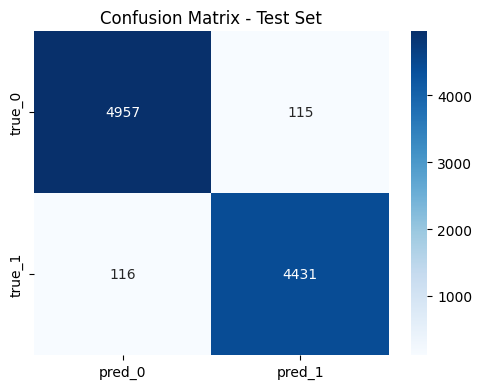

In [18]:
print(classification_report(y_test, y_pred, digits=4))

cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=["true_0", "true_1"], columns=["pred_0", "pred_1"])
display(cm_df)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Test Set")
plt.tight_layout()
plt.savefig(FIG_DIR / "pokemon_model_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

### Conclusión de diagnóstico de errores

El classification report y la matriz de confusión permiten analizar dónde falla el modelo por clase.

Uso práctico de esta sección:
- detectar sesgos de predicción entre clases,
- priorizar acciones de mejora (features, umbral, calibración o costo de error).

In [19]:
threshold_summary_df = pd.DataFrame()

if y_proba is not None:
    precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

    f1_vals = (2 * precision * recall) / np.clip(precision + recall, a_min=1e-12, a_max=None)
    valid_len = len(thresholds)

    threshold_summary_df = pd.DataFrame({
        "threshold": thresholds,
        "precision": precision[:valid_len],
        "recall": recall[:valid_len],
        "f1": f1_vals[:valid_len],
    }).sort_values(by="f1", ascending=False).reset_index(drop=True)

    best_threshold = float(threshold_summary_df.loc[0, "threshold"])
    y_pred_best_f1 = (y_proba >= best_threshold).astype(int)
    best_threshold_f1 = float(f1_score(y_test, y_pred_best_f1))

    print(f"Best threshold by test F1: {best_threshold:.4f}")
    print(f"F1 at default threshold (0.5): {test_metrics['f1']:.4f}")
    print(f"F1 at best threshold: {best_threshold_f1:.4f}")
    display(threshold_summary_df.head(10).round(4))
else:
    print("Threshold analysis skipped: selected estimator does not expose predict_proba.")

Best threshold by test F1: 0.4541
F1 at default threshold (0.5): 0.9746
F1 at best threshold: 0.9758


,threshold,precision,recall,f1
0,0.4541,0.9733,0.9782,0.9758
1,0.4541,0.9731,0.9782,0.9757
2,0.4548,0.9733,0.9780,0.9756
3,0.4564,0.9735,0.9778,0.9756
4,0.4586,0.9737,0.9776,0.9756
5,0.4610,0.9739,0.9773,0.9756
6,0.4497,0.9729,0.9782,0.9755
7,0.4556,0.9733,0.9778,0.9755
8,0.4564,0.9735,0.9776,0.9755
9,0.4598,0.9737,0.9773,0.9755


### Conclusión de análisis de umbral

El análisis de umbral traduce probabilidades en decisiones operativas según el costo de error.

Alcance de esta decisión:
- no reemplaza la selección del modelo,
- sí permite ajustar política de predicción para distintos objetivos de negocio (priorizar recall o precision).

In [20]:
importance_df = pd.DataFrame()

preprocess_step = final_model_pipeline.named_steps["preprocess"]
model_step = final_model_pipeline.named_steps["model"]
feature_names = preprocess_step.get_feature_names_out()

if hasattr(model_step, "feature_importances_"):
    importance_values = model_step.feature_importances_
    importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance": importance_values,
    }).sort_values(by="importance", ascending=False).reset_index(drop=True)

elif hasattr(model_step, "coef_"):
    coef = np.asarray(model_step.coef_).ravel()
    importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance": np.abs(coef),
    }).sort_values(by="importance", ascending=False).reset_index(drop=True)

if not importance_df.empty:
    display(importance_df.head(20))

    plt.figure(figsize=(10, 6))
    plot_df = importance_df.head(15).iloc[::-1]
    plt.barh(plot_df["feature"], plot_df["importance"], color="#4C72B0")
    plt.title("Top 15 feature importances (model-level)")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "pokemon_model_top_feature_importances.png", dpi=150, bbox_inches="tight")
    plt.show()

    importance_df.to_csv(REPORTS_DIR / "pokemon_model_feature_importance.csv", index=False)
else:
    print("Feature importance export skipped: estimator has no direct importances/coefs.")

Feature importance export skipped: estimator has no direct importances/coefs.


### Conclusión de interpretabilidad

La importancia de variables conecta el resultado del modelo con hipótesis de EDA y conocimiento del dominio Pokemon.

Valor técnico:
- facilita explicar el comportamiento del modelo,
- permite validar si las señales más relevantes tienen sentido causal o al menos correlacional razonable.

In [25]:
final_model_path = ARTIFACTS_DIR / "final_model_pipeline_pokemon.joblib"
model_selection_report_path = REPORTS_DIR / "pokemon_model_selection_results.csv"
test_metrics_path = REPORTS_DIR / "pokemon_test_metrics.json"
model_card_path = ARTIFACTS_DIR / "model_card_pokemon.json"

joblib.dump(final_model_pipeline, final_model_path)
final_comparison_df.to_csv(model_selection_report_path, index=False)

with open(test_metrics_path, "w", encoding="utf-8") as f:
    json.dump(test_metrics, f, ensure_ascii=False, indent=2)

model_card = {
    "selected_model": selected_model_name,
    "random_state": RANDOM_STATE,
    "cv_strategy": {
        "type": "StratifiedKFold",
        "n_splits": N_SPLITS,
        "shuffle": True,
        "random_state": RANDOM_STATE,
    },
    "selection_metric": "cv_f1_mean",
    "test_metrics": test_metrics,
    "data_artifacts": {
        "preprocess_pipeline": str(preprocess_pipeline_path),
        "split_data": str(split_data_path),
        "feature_manifest": str(feature_manifest_path),
    },
}

with open(model_card_path, "w", encoding="utf-8") as f:
    json.dump(model_card, f, ensure_ascii=False, indent=2)

print("Saved:")
print("-", final_model_path)
print("-", model_selection_report_path)
print("-", test_metrics_path)
print("-", model_card_path)

Saved:
- ../artifacts/final_model_pipeline_pokemon.joblib
- ../reports/pokemon_model_selection_results.csv
- ../reports/pokemon_test_metrics.json
- ../artifacts/model_card_pokemon.json


### Conclusión de persistencia y gobernanza

La persistencia final asegura continuidad entre experimentación, despliegue y auditoría.

Se guardan:
- pipeline final entrenado,
- comparativa de selección,
- métricas de test,
- model card con contexto metodológico.

Con esto, cualquier integrante del equipo puede reconstruir qué modelo se eligió, por qué se eligió y con qué evidencia.

## Conclusiones ejecutivas del modeling

1. El pipeline de modelado mantiene consistencia total con EDA y Data Preparation, evitando reconstrucciones manuales y riesgo de fuga.
2. La selección de modelos se realizó con un protocolo único de CV estratificada y métrica principal F1, lo que garantiza comparabilidad.
3. Se corrigió el flujo técnico para modelos que requieren entrada densa, eliminando fallos de ejecución en candidatos de boosting.
4. El tuning con Optuna se aplicó de forma focalizada sobre modelos competitivos, optimizando costo computacional y rigor metodológico.
5. La evaluación en test se conserva como instancia final y única, preservando la validez de generalización.
6. Los artefactos persistidos permiten trazabilidad, reproducibilidad y gobernanza del ciclo de vida del modelo.

## Próximos pasos recomendados

1. Incorporar análisis de error por subgrupos (Legendary, is_mega, combinaciones de tipo) para detectar sesgos específicos.
2. Evaluar calibración probabilística si la operación depende de umbrales dinámicos.
3. Implementar notebook o script de inferencia que cargue el pipeline final y registre versiones de entrada/salida.